In [9]:
import csv
import json
import re
import random
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict, Any, Tuple

import numpy as np
import soundfile as sf

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import torchaudio
from transformers import HubertModel, Wav2Vec2FeatureExtractor, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Config
MANIFESTS = [
    Path('/home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl'),
    Path('/home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl'),
]
CSV_PATH = Path('/home/huy/207177/data/original_learner_dataset/database_backup/full_assessment.csv')

PRETRAINED = 'TencentGameMate/chinese-hubert-large'
SR = 16000

EXP_TAG = 'hubert_large_zh_learner'
SAVE_DIR = Path('/home/huy/207177/output/checkpoint') / EXP_TAG
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPK_TXT = Path('/home/huy/207177/output/testing') / f'test_speakers_{EXP_TAG}.txt'

SEED = 1337
BATCH_SIZE = 1
LR_HEAD = 1e-4
LR_FULL = 1e-5
FREEZE_UPDATES = 5000
TOTAL_UPDATES = 30000
WARMUP_UPDATES = 1000
EVAL_EVERY = 1000
MASK_SPEECH_MIN_FRAMES = 5

TEST_SPK_RATIO = 0.20
DEV_SPK_RATIO_IN_TRAIN = 0.05
MIN_DEV_SPK = 10

label2id = {'T1': 0, 'T2': 1, 'T3': 2, 'T4': 3, 'T5': 4}
id2label = {v: k for k, v in label2id.items()}
MODEL_TONE_TO_CSV = {'T1': '1', 'T2': '2', 'T3': '3', 'T4': '4', 'T5': '0'}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
for p in MANIFESTS:
    print('Manifest:', p, 'exists:', p.exists())
print('CSV:', CSV_PATH, 'exists:', CSV_PATH.exists())
print('Save dir:', SAVE_DIR)

Device: cuda
Manifest: /home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl exists: True
Manifest: /home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl exists: True
CSV: /home/huy/207177/data/original_learner_dataset/database_backup/full_assessment.csv exists: True
Save dir: /home/huy/207177/output/checkpoint/hubert_large_zh_learner


In [11]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def read_manifest(path: Path) -> List[Dict[str, Any]]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(x) for x in f if x.strip()]

def read_manifests(paths: List[Path]) -> List[Dict[str, Any]]:
    all_items: List[Dict[str, Any]] = []
    for p in paths:
        if not p.exists():
            print('Warning missing:', p)
            continue
        items = read_manifest(p)
        print(f'Loaded {len(items)} from {p}')
        all_items.extend(items)
    print('Total learner items:', len(all_items))
    return all_items

def load_csv_tone_table(csv_path: Path):
    tone_map: Dict[str, Dict[str, Dict[int, str]]] = {}
    with csv_path.open('r', encoding='utf-8-sig', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            spk = str(row['id']).strip()
            d_a = {}
            d_q = {}
            for n in range(0, 11):
                v = row.get(f'a{n}t', None)
                if v is None or str(v).strip() == '' or str(v).upper() == 'NULL':
                    d_a[n] = None
                else:
                    d_a[n] = str(int(float(v)))
            for n in range(1, 19):
                v = row.get(f'q{n}t', None)
                if v is None or str(v).strip() == '' or str(v).upper() == 'NULL':
                    d_q[n] = None
                else:
                    d_q[n] = str(int(float(v)))
            tone_map[spk] = {'a': d_a, 'q': d_q}
    return tone_map

def get_speaker_id(ex: Dict[str, Any]) -> str:
    utt = str(ex.get('utt', ''))
    return utt.split('__')[0] if '__' in utt else utt

def tone_to_id(tone_csv: str) -> int:
    lab = 'T5' if str(tone_csv) == '0' else f'T{str(tone_csv)}'
    return label2id[lab]

def csv_tone_from_utt(utt: str, tone_map: Dict[str, Dict[str, Dict[int, str]]]):
    m_a = re.match(r'^(.+)__a(\d+)$', utt)
    if m_a:
        spk = m_a.group(1)
        idx = int(m_a.group(2))
        if spk in tone_map:
            return tone_map[spk]['a'].get(idx)
        return None

    m_q = re.match(r'^(.+)__q(\d+)$', utt)
    if m_q:
        spk = m_q.group(1)
        idx = int(m_q.group(2))
        if spk in tone_map:
            return tone_map[spk]['q'].get(idx)
        return None

    return None

def split_by_speaker(items: List[Dict[str, Any]]):
    spk2items: Dict[str, List[Dict[str, Any]]] = {}
    for ex in items:
        spk = get_speaker_id(ex)
        spk2items.setdefault(spk, []).append(ex)

    speakers = sorted(spk2items.keys())
    random.shuffle(speakers)

    n_spk = len(speakers)
    test_n = max(1, int(TEST_SPK_RATIO * n_spk))
    test_speakers = speakers[:test_n]
    train_all = speakers[test_n:]

    dev_n = max(MIN_DEV_SPK, int(DEV_SPK_RATIO_IN_TRAIN * len(train_all)))
    dev_n = min(dev_n, max(1, len(train_all) - 1))
    dev_speakers = train_all[:dev_n]
    train_speakers = train_all[dev_n:]

    train_items = [x for spk in train_speakers for x in spk2items[spk]]
    dev_items = [x for spk in dev_speakers for x in spk2items[spk]]
    test_items = [x for spk in test_speakers for x in spk2items[spk]]

    TEST_SPK_TXT.parent.mkdir(parents=True, exist_ok=True)
    TEST_SPK_TXT.write_text('\n'.join(sorted(test_speakers)) + '\n', encoding='utf-8')

    print('Speakers total:', n_spk)
    print('Train speakers:', len(train_speakers), 'Dev speakers:', len(dev_speakers), 'Test speakers:', len(test_speakers))
    print('Train/Dev/Test items:', len(train_items), len(dev_items), len(test_items))
    print('Test speaker list:', TEST_SPK_TXT)
    return train_items, dev_items, test_items

class ToneDataset(Dataset):
    def __init__(self, items: List[Dict[str, Any]]):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]

class FrameToneModel(nn.Module):

    def __init__(self, pretrained: str, num_labels: int):
        super().__init__()
        self.w2v = HubertModel.from_pretrained(pretrained)
        #freeze CNN manually
        for param in self.w2v.feature_extractor.parameters():
            param.requires_grad = False

        n_layers = self.w2v.config.num_hidden_layers + 1
        self.layer_weights = nn.Parameter(torch.zeros(n_layers))
        self.proj = nn.Linear(self.w2v.config.hidden_size, num_labels)

    def freeze_encoder(self):
        for p in self.w2v.parameters():
            p.requires_grad = False

    def unfreeze_transformer(self):
        for n, p in self.w2v.named_parameters():
            if not n.startswith('feature_extractor'):
                p.requires_grad = True

    def forward(self, input_values, attention_mask=None):
        out = self.w2v(
            input_values=input_values,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        stack = torch.stack(out.hidden_states, dim=0)
        weights = torch.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        fused = (stack * weights).sum(dim=0)
        return self.proj(fused)

def nearest_resample(mask_25ms: torch.Tensor, n_frames: int):
    L = mask_25ms.numel()
    if L == 0 or n_frames <= 0:
        return torch.zeros(n_frames, dtype=torch.bool)
    idx = torch.linspace(0, L - 1, steps=n_frames)
    idx = torch.round(idx).long().clamp(0, L - 1)
    return mask_25ms[idx].bool()

def majority_tone_from_logits(logits_f: torch.Tensor, mask_f: torch.Tensor, id2label: Dict[int, str]):
    pred_ids = logits_f.argmax(dim=-1)[mask_f].detach().cpu().tolist()
    mapped = []
    for pid in pred_ids:
        lbl = id2label.get(int(pid), None)
        if lbl in MODEL_TONE_TO_CSV:
            mapped.append(MODEL_TONE_TO_CSV[lbl])
    if len(mapped) == 0:
        return None
    counts: Dict[str, int] = {}
    for t in mapped:
        counts[t] = counts.get(t, 0) + 1
    return max(counts, key=counts.get)

@dataclass
class Collator:
    feature_extractor: Wav2Vec2FeatureExtractor

    def _load_audio(self, path: str):
        audio, sr = sf.read(path, dtype='float32')
        if audio.ndim == 2:
            audio = audio.mean(axis=1)
        if sr != SR:
            audio = torchaudio.functional.resample(torch.from_numpy(audio), sr, SR).numpy()
        return audio.astype(np.float32)

    def _load_mask(self, path: str):
        seq = Path(path).read_text(encoding='utf-8').strip().split()
        if not seq:
            return torch.zeros(0, dtype=torch.bool)
        return torch.tensor([int(x) for x in seq], dtype=torch.bool)

    def __call__(self, batch):
        wavs, masks, tones, utts = [], [], [], []
        for ex in batch:
            wavs.append(self._load_audio(ex['audio']))
            masks.append(self._load_mask(ex['mask']))
            tones.append(str(ex['tone']))
            utts.append(str(ex['utt']))

        inputs = self.feature_extractor(
            wavs,
            sampling_rate=SR,
            return_tensors='pt',
            padding=True,
            return_attention_mask=True,
        )
        return {
            'input_values': inputs['input_values'],
            'attention_mask': inputs.get('attention_mask'),
            'masks_25ms': masks,
            'tones': tones,
            'utts': utts,
        }

In [12]:
@torch.no_grad()
def evaluate_utterance_acc(
    model: nn.Module,
    loader: DataLoader,
    device: str,
    tone_map: Dict[str, Dict[str, Dict[int, str]]],
):
    model.eval()
    correct, total = 0, 0
    skipped_no_csv = 0
    skipped_no_pred = 0

    for batch in loader:
        x = batch['input_values'].to(device)
        m = batch['attention_mask']
        if m is not None:
            m = m.to(device)

        logits = model(x, m)
        B, F, _ = logits.shape

        for b in range(B):
            utt = batch['utts'][b]
            true_tone = csv_tone_from_utt(utt, tone_map)
            if true_tone is None:
                skipped_no_csv += 1
                continue

            mask_f = nearest_resample(batch['masks_25ms'][b], F).to(device)
            if mask_f.sum() < MASK_SPEECH_MIN_FRAMES:
                mask_f = torch.ones(F, dtype=torch.bool, device=device)

            pred_tone = majority_tone_from_logits(logits[b], mask_f, id2label)
            if pred_tone is None:
                skipped_no_pred += 1
                continue

            correct += int(pred_tone == true_tone)
            total += 1

    model.train()
    return correct / max(1, total), {
        'compared': total,
        'skipped_no_csv': skipped_no_csv,
        'skipped_no_pred': skipped_no_pred,
    }


@torch.no_grad()
def evaluate_predictions(
    model: nn.Module,
    loader: DataLoader,
    device: str,
    tone_map: Dict[str, Dict[str, Dict[int, str]]],
) -> Tuple[List[str], List[str], Dict[str, int]]:
    model.eval()
    y_true: List[str] = []
    y_pred: List[str] = []
    skipped_no_csv = 0
    skipped_no_pred = 0

    for batch in loader:
        x = batch['input_values'].to(device)
        m = batch['attention_mask']
        if m is not None:
            m = m.to(device)

        logits = model(x, m)
        B, F, _ = logits.shape

        for b in range(B):
            utt = batch['utts'][b]
            true_tone = csv_tone_from_utt(utt, tone_map)
            if true_tone is None:
                skipped_no_csv += 1
                continue

            mask_f = nearest_resample(batch['masks_25ms'][b], F).to(device)
            if mask_f.sum() < MASK_SPEECH_MIN_FRAMES:
                mask_f = torch.ones(F, dtype=torch.bool, device=device)

            pred_tone = majority_tone_from_logits(logits[b], mask_f, id2label)
            if pred_tone is None:
                skipped_no_pred += 1
                continue

            y_true.append(true_tone)
            y_pred.append(pred_tone)

    model.train()
    return y_true, y_pred, {
        'compared': len(y_true),
        'skipped_no_csv': skipped_no_csv,
        'skipped_no_pred': skipped_no_pred,
    }

In [13]:
TONE_LABELS = ['0', '1', '2', '3', '4']
TONE_TARGET_NAMES = ['T5/neutral', 'T1', 'T2', 'T3', 'T4']


def train_learner_only():
    set_seed(SEED)
    items = read_manifests(MANIFESTS)
    if len(items) == 0:
        raise RuntimeError('No learner data loaded from MANIFESTS')

    tone_map = load_csv_tone_table(CSV_PATH)
    train_items, dev_items, test_items = split_by_speaker(items)

    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED)
    train_loader = DataLoader(
        ToneDataset(train_items),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )
    dev_loader = DataLoader(
        ToneDataset(dev_items),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )
    test_loader = DataLoader(
        ToneDataset(test_items),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=Collator(feature_extractor),
    )

    model = FrameToneModel(PRETRAINED, num_labels=len(label2id)).to(DEVICE)
    model.w2v.config.apply_spec_augment = False
    model.w2v.config.mask_time_prob = 0.0
    model.w2v.config.mask_feature_prob = 0.0
    model.freeze_encoder()

    optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_HEAD)
    sched = get_linear_schedule_with_warmup(optim, WARMUP_UPDATES, TOTAL_UPDATES)
    loss_fn = nn.CrossEntropyLoss()

    best_dev = 0.0
    step = 0
    curves = {
        'exp_tag': EXP_TAG,
        'pretrained': PRETRAINED,
        'freeze_updates': int(FREEZE_UPDATES),
        'eval_every': int(EVAL_EVERY),
        'total_updates': int(TOTAL_UPDATES),
        'train_step': [],
        'train_loss': [],
        'dev_step': [],
        'dev_acc': [],
    }
    pbar = tqdm(total=TOTAL_UPDATES, desc=EXP_TAG)

    while step < TOTAL_UPDATES:
        for batch in train_loader:
            x = batch['input_values'].to(DEVICE)
            m = batch['attention_mask']
            if m is not None:
                m = m.to(DEVICE)

            logits = model(x, m)
            B, F, _ = logits.shape

            loss_sum = 0.0
            valid_n = 0
            for b in range(B):
                mask_f = nearest_resample(batch['masks_25ms'][b], F).to(DEVICE)
                if mask_f.sum() < MASK_SPEECH_MIN_FRAMES:
                    mask_f = torch.ones(F, dtype=torch.bool, device=DEVICE)

                gold_id = tone_to_id(batch['tones'][b])
                y = torch.full((F,), gold_id, device=DEVICE)
                if mask_f.sum() > 0:
                    loss_sum += loss_fn(logits[b][mask_f], y[mask_f])
                    valid_n += 1

            if valid_n == 0:
                continue

            loss = loss_sum / valid_n
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optim.step()
            sched.step()
            optim.zero_grad(set_to_none=True)

            step += 1
            curves['train_step'].append(int(step))
            curves['train_loss'].append(float(loss.item()))
            pbar.update(1)
            pbar.set_postfix(loss=float(loss.item()))

            if step == FREEZE_UPDATES:
                print('\nUnfreezing wav2vec2 transformer')
                model.unfreeze_transformer()
                optim = torch.optim.AdamW(
                    [p for p in model.parameters() if p.requires_grad],
                    lr=LR_FULL,
                )
                sched = get_linear_schedule_with_warmup(
                    optim,
                    WARMUP_UPDATES,
                    max(1, TOTAL_UPDATES - FREEZE_UPDATES),
                )

            if step % EVAL_EVERY == 0:
                dev_acc, dev_info = evaluate_utterance_acc(model, dev_loader, DEVICE, tone_map)
                curves['dev_step'].append(int(step))
                curves['dev_acc'].append(float(dev_acc))
                print(
                    f"\nstep {step}: dev_acc={dev_acc:.4f}, compared={dev_info['compared']}, "
                    f"no_csv={dev_info['skipped_no_csv']}, no_pred={dev_info['skipped_no_pred']}"
                )
                if dev_acc > best_dev:
                    best_dev = dev_acc
                    torch.save(
                        {'model': model.state_dict(), 'label2id': label2id},
                        SAVE_DIR / 'best.pt',
                    )
                    print('saved best.pt')

            if step >= TOTAL_UPDATES:
                break

    pbar.close()
    torch.save({'model': model.state_dict(), 'label2id': label2id}, SAVE_DIR / 'last.pt')
    print('Saved last.pt')

    print('\nFinal evaluation on test split:')
    y_true, y_pred, test_info = evaluate_predictions(model, test_loader, DEVICE, tone_map)
    test_acc = (
        sum(int(t == p) for t, p in zip(y_true, y_pred)) / len(y_true)
        if y_true else 0.0
    )
    print(
        f"test_acc={test_acc:.4f}, compared={test_info['compared']}, "
        f"no_csv={test_info['skipped_no_csv']}, no_pred={test_info['skipped_no_pred']}"
    )

    cls_report_dict = classification_report(
        y_true,
        y_pred,
        labels=TONE_LABELS,
        target_names=TONE_TARGET_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    print(classification_report(
        y_true,
        y_pred,
        labels=TONE_LABELS,
        target_names=TONE_TARGET_NAMES,
        digits=4,
        zero_division=0,
    ))
    cm = confusion_matrix(y_true, y_pred, labels=TONE_LABELS)
    print('Confusion matrix:'.format(TONE_LABELS))
    print(cm)

    summary = {
        'exp_tag': EXP_TAG,
        'pretrained': PRETRAINED,
        'best_dev_acc': float(best_dev),
        'test_acc': float(test_acc),
        'test_info': test_info,
        'train_items': len(train_items),
        'dev_items': len(dev_items),
        'test_items': len(test_items),
        'save_dir': str(SAVE_DIR),
        'training_curves': str((SAVE_DIR / 'training_curves.json').resolve()),
        'tone_labels': TONE_LABELS,
        'tone_target_names': TONE_TARGET_NAMES,
        'classification_report': cls_report_dict,
        'confusion_matrix': cm.tolist(),
    }
    with (SAVE_DIR / 'training_curves.json').open('w', encoding='utf-8') as f:
        json.dump(curves, f, ensure_ascii=False, indent=2)
    print('Saved training_curves.json')

    with (SAVE_DIR / 'summary.json').open('w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print('Saved summary.json')

    return curves

In [14]:
history = train_learner_only()

Loaded 6623 from /home/huy/207177/data/mfa/manifests/learner_dataset/stageI.jsonl
Loaded 4700 from /home/huy/207177/data/mfa/manifests/learner_dataset/stageII.jsonl
Total learner items: 11323
Speakers total: 678
Train speakers: 516 Dev speakers: 27 Test speakers: 135
Train/Dev/Test items: 8577 464 2282
Test speaker list: /home/huy/207177/output/testing/test_speakers_hubert_large_zh_learner.txt


/home/huy/.conda/envs/tone_ce/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at TencentGameMate/chinese-hubert-large were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not i


step 1000: dev_acc=0.3556, compared=464, no_csv=0, no_pred=0


hubert_large_zh_learner:   3%|▎         | 1003/30000 [00:36<1:55:50,  4.17it/s, loss=2.45]

saved best.pt


...

hubert_large_zh_learner:  97%|█████████▋| 29001/30000 [56:17<11:15,  1.48it/s, loss=0.598]   


step 29000: dev_acc=0.7909, compared=464, no_csv=0, no_pred=0


hubert_large_zh_learner: 100%|██████████| 30000/30000 [58:24<00:00,  8.56it/s, loss=1.25]    


step 30000: dev_acc=0.7909, compared=464, no_csv=0, no_pred=0


Saved last.pt

Final evaluation on test split:
test_acc=0.7993, compared=2282, no_csv=0, no_pred=0
              precision    recall  f1-score   support

  T5/neutral     0.6479    0.5565    0.5987       248
          T1     0.8098    0.8388    0.8240       670
          T2     0.8274    0.8251    0.8263       732
          T3     0.5205    0.6080    0.5609       125
          T4     0.8898    0.8757    0.8827       507

    accuracy                         0.7993      2282
   macro avg     0.7391    0.7408    0.7385      2282
weighted avg     0.7998    0.7993    0.7989      2282

Confusion matrix:
[[138  25  39  23  23]
 [ 19 562  59  10  20]
 [ 34  69 604  22   3]
 [ 11   8  21  76   9]
 [ 11  30   7  15 444]]
Saved training_curves.json
Saved summary.json


Wrote /home/huy/207177/output/checkpoint/hubert_large_zh_learner/training_curves.png


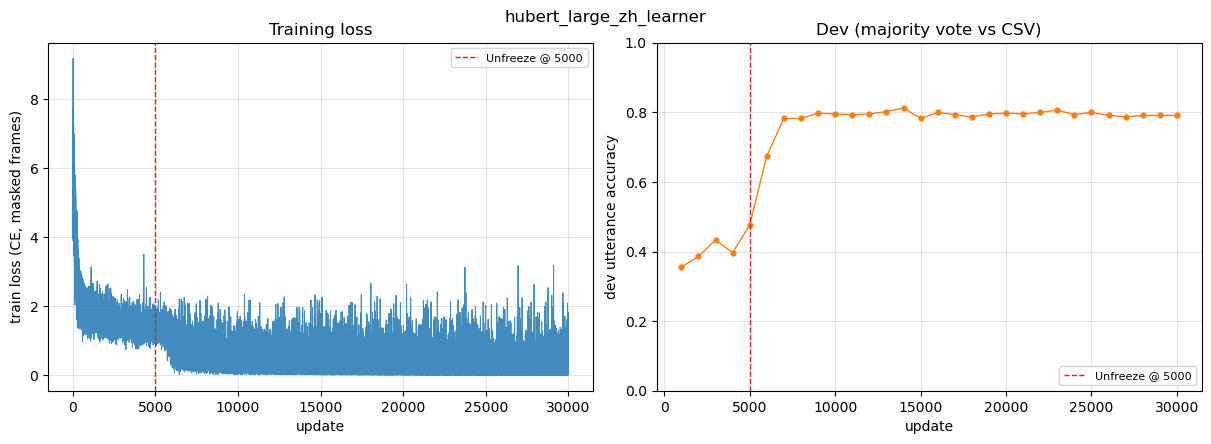

In [15]:

import json
import matplotlib.pyplot as plt

def plot_w2v_training_curves(curves: dict = None, save_fig: bool = True) -> None:
    if curves is None:
        p = SAVE_DIR / "training_curves.json"
        if not p.is_file():
            print("No in-memory `history` and no file:", p)
            return
        with p.open("r", encoding="utf-8") as f:
            curves = json.load(f)

    t_step = curves.get("train_step", [])
    t_loss = curves.get("train_loss", [])
    d_step = curves.get("dev_step", [])
    d_acc = curves.get("dev_acc", [])
    fu = curves.get("freeze_updates", FREEZE_UPDATES)
    tag = curves.get("exp_tag", EXP_TAG)

    if not t_step and not d_step:
        print("No curve data in dict.")
        return

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
    if t_step and t_loss:
        ax0.plot(t_step, t_loss, color="C0", lw=0.7, alpha=0.85)
    ax0.axvline(fu, color="C3", ls="--", lw=1.0, label=f"Unfreeze @ {fu}")
    ax0.set_xlabel("update")
    ax0.set_ylabel("train loss (CE, masked frames)")
    ax0.set_title("Training loss")
    ax0.grid(True, alpha=0.35)
    ax0.legend(loc="upper right", fontsize=8)

    if d_step and d_acc:
        ax1.plot(d_step, d_acc, color="C1", marker="o", ms=3.5, lw=1.0)
    ax1.axvline(fu, color="C3", ls="--", lw=1.0, label=f"Unfreeze @ {fu}")
    ax1.set_xlabel("update")
    ax1.set_ylabel("dev utterance accuracy")
    ax1.set_title("Dev (majority vote vs CSV)")
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.35)
    ax1.legend(loc="lower right", fontsize=8)

    fig.suptitle(tag, y=1.02)
    if save_fig:
        out = SAVE_DIR / "training_curves.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print("Wrote", out)
    plt.show()

_c = globals().get("history")
plot_w2v_training_curves(curves=_c, save_fig=True)

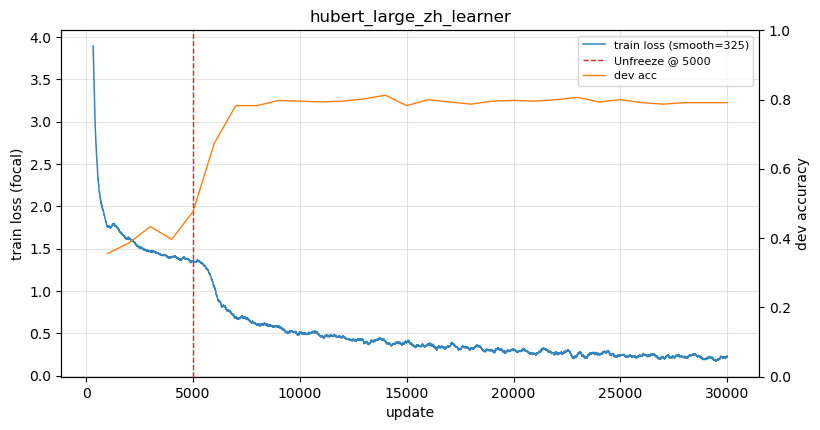

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def _smooth_curve(values, window: int = 25):
    if len(values) < 3 or window <= 1:
        return values
    window = min(window, len(values))
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def plot_loss_and_accuracy(curves: dict = None, smooth_window: int = 25) -> None:
    if curves is None:
        p = SAVE_DIR / "training_curves.json"
        if not p.is_file():
            print("No in-memory history and no file:", p)
            return
        with p.open("r", encoding="utf-8") as f:
            curves = json.load(f)

    t_step = curves.get("train_step", [])
    t_loss = curves.get("train_loss", [])
    d_step = curves.get("dev_step", [])
    d_acc = curves.get("dev_acc", [])
    fu = curves.get("freeze_updates", FREEZE_UPDATES)
    tag = curves.get("exp_tag", EXP_TAG)

    if not t_step and not d_step:
        print("No curve data in dict.")
        return

    fig, ax1 = plt.subplots(figsize=(9, 4.5))
    if t_step and t_loss:
        t_loss_sm = _smooth_curve(t_loss, window=smooth_window)
        t_step_sm = t_step[len(t_step) - len(t_loss_sm):]
        ax1.plot(t_step_sm, t_loss_sm, color="C0", lw=1.1, alpha=0.9, label=f"train loss (smooth={smooth_window})")
        
    ax1.set_xlabel("update")
    ax1.set_ylabel("train loss (focal)")
    ax1.grid(True, alpha=0.35)
    ax1.axvline(fu, color="C3", ls="--", lw=1.0, label=f"Unfreeze @ {fu}")

    ax2 = ax1.twinx()
    if d_step and d_acc:
        ax2.plot(d_step, d_acc, color="C1", ms=3.2, lw=1.0, label="dev acc")
    ax2.set_ylabel("dev accuracy")
    ax2.set_ylim(0, 1.0)

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=8)
    ax1.set_title(tag)
    plt.show()

_c = globals().get("history")
plot_loss_and_accuracy(curves=_c, smooth_window=325)